In [1]:
#ML - Final Model - Training Model - Phase 1 - Classification - Logistic Regression - Algorithm

Problem Statement:

Develop a machine learning model to predict whether a customer will respond to a marketing campaign based on demographic information, income, purchasing behavior, and website activity. The objective is to help businesses identify customers who are most likely to respond, thereby improving campaign effectiveness and reducing marketing costs.

In [2]:
#1.IMPORTING REQUIRED LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#import numpy as np              → Loads numpy, used for numerical operations and arrays
#import matplotlib.pyplot as plt → Loads matplotlib's plotting module, used to create graphs and charts
#import pandas as pd             → Loads pandas, used to work with data in table form

#These three libraries together let us handle numbers, data tables, and visualizations.

In [3]:
#2.LOADING AND VIEWING THE DATASET
dataset=pd.read_csv("superstore_data.csv") 
dataset

#pd.read_csv("superstore_data.csv")   → Reads data from the CSV file into a table format
#dataset = ...                          → Stores this data table in a variable called dataset
#dataset                                 → Displays the dataset so we can view its contents

#This loads the superstore data from a CSV file and shows it as a table.

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,7/3/2013,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [4]:
#3.REMOVING UNNEEDED COLUMNS
dataset.drop(['Id', 'Dt_Customer'], axis=1, inplace=True)
dataset

#dataset.drop(['Id', 'Dt_Customer'], axis=1, inplace=True)   → Removes the 'Id' and 'Dt_Customer' columns from the dataset
#axis=1                                                        → Tells pandas we're dropping columns (not rows)
#inplace=True                                                  → Directly updates dataset without needing to reassign it
#dataset                                                        → Displays the updated dataset

#These columns aren't useful for the model, so they're removed to keep the data clean.

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1970,Graduation,Divorced,84835.0,0,0,0,189,104,379,111,189,218,1,4,4,6,1,1,0
1,1961,Graduation,Single,57091.0,0,0,0,464,5,64,7,0,37,1,7,3,7,5,1,0
2,1958,Graduation,Married,67267.0,0,1,0,134,11,59,15,2,30,1,3,2,5,2,0,0
3,1967,Graduation,Together,32474.0,1,1,0,10,0,1,0,0,0,1,1,0,2,7,0,0
4,1989,Graduation,Single,21474.0,1,0,0,6,16,24,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1976,PhD,Divorced,66476.0,0,1,99,372,18,126,47,48,78,2,5,2,11,4,0,0
2236,1977,2n Cycle,Married,31056.0,1,0,99,5,10,13,3,8,16,1,1,0,3,8,0,0
2237,1976,Graduation,Divorced,46310.0,1,0,99,185,2,88,15,5,14,2,6,1,5,8,0,0
2238,1978,Graduation,Married,65819.0,0,0,99,267,38,701,149,165,63,1,5,4,10,3,0,0


In [5]:
#4.CONVERTING CATEGORICAL COLUMNS INTO NUMBERS
dataset=pd.get_dummies(dataset,drop_first=True)
dataset

#pd.get_dummies(dataset, drop_first=True)   → Converts categorical (text) columns into numeric 0/1 columns
#drop_first=True                              → Drops the first category of each column to avoid duplicate/redundant info
#dataset = ...                                 → Stores the updated dataset with numeric columns
#dataset                                        → Displays the updated dataset

#Machine learning models need numbers, so this converts text categories into 0s and 1s.

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1970,84835.0,0,0,0,189,104,379,111,189,...,True,False,False,False,True,False,False,False,False,False
1,1961,57091.0,0,0,0,464,5,64,7,0,...,True,False,False,False,False,False,True,False,False,False
2,1958,67267.0,0,1,0,134,11,59,15,2,...,True,False,False,False,False,True,False,False,False,False
3,1967,32474.0,1,1,0,10,0,1,0,0,...,True,False,False,False,False,False,False,True,False,False
4,1989,21474.0,1,0,0,6,16,24,11,0,...,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1976,66476.0,0,1,99,372,18,126,47,48,...,False,False,True,False,True,False,False,False,False,False
2236,1977,31056.0,1,0,99,5,10,13,3,8,...,False,False,False,False,False,True,False,False,False,False
2237,1976,46310.0,1,0,99,185,2,88,15,5,...,True,False,False,False,True,False,False,False,False,False
2238,1978,65819.0,0,0,99,267,38,701,149,165,...,True,False,False,False,False,True,False,False,False,False


In [6]:
#5.CHECKING THE BALANCE OF THE TARGET VARIABLE
dataset["Response"].value_counts() #To Identify Balanced or Imbalanced Value Counts

#dataset["Response"].value_counts()   → Counts how many times each unique value appears in the "Response" column

#This checks whether the target column is balanced (similar counts) or imbalanced (one value is much more common than the other).

Response
0    1906
1     334
Name: count, dtype: int64

In [7]:
#6.SPLITTING DATA INTO INPUT (X) AND OUTPUT (Y)
indep=dataset[["Income", "Kidhome", "Teenhome", "Recency", "MntWines"]]
dep=dataset["Response"]

#dataset[[...]]   → Selects multiple columns from the dataset to use as input features
#indep = ...        → Stores these selected columns as the independent variables (inputs)
#dataset["Response"]   → Selects the "Response" column, which is what we want to predict
#dep = ...              → Stores this column as the dependent variable (output)

#This separates the data into inputs (indep) and the target we want to predict (dep).

In [8]:
#7.CHECKING THE SHAPE OF INPUT DATA
indep.shape

#indep.shape   → Shows the number of rows and columns in indep

#This confirms how many samples and features are present in the input data.

(2240, 5)

In [9]:
#8.DISPLAYING THE TARGET VARIABLE
dep

#dep   → Displays the values stored in dep, the target variable

#This shows the actual output/target values used for training the model.

0       1
1       1
2       0
3       0
4       1
       ..
2235    0
2236    0
2237    0
2238    0
2239    1
Name: Response, Length: 2240, dtype: int64

In [10]:
#9.CHECKING NULL VALUES IN INPUT DATA
print(indep.isnull().sum())

#indep.isnull().sum()   → Counts the number of missing (null) values in each column of indep

#This checks whether the input features have any missing values before training the model.

Income      24
Kidhome      0
Teenhome     0
Recency      0
MntWines     0
dtype: int64


In [11]:
#10.HANDLING MISSING VALUES USING SIMPLEIMPUTER
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy='mean')  
indep_imputed = imputer.fit_transform(indep)

#from sklearn.impute import SimpleImputer   → Imports the tool used to fill in missing values
#import numpy as np                          → Imports numpy for numerical operations
#SimpleImputer(strategy='mean')              → Creates an imputer that fills missing values with the column's mean
#imputer = ...                                → Stores this imputer object
#imputer.fit_transform(indep)                → Learns the mean of each column and fills in missing values in indep
#indep_imputed = ...                          → Stores the updated data with missing values filled in

#This replaces missing values in the data with the average (mean) of each column, so the model can be trained without errors.

In [12]:
#11.TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(indep_imputed, dep, test_size = 1/3, random_state = 0)

#from sklearn.model_selection import train_test_split          → Imports the tool used to split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(...)       → Splits indep_imputed (features) and dep (target) into training and testing sets
#indep_imputed                                                  → Independent variables with missing values already filled in
#dep                                                             → Dependent variable (target)
#test_size = 1/3                                                → 33% of data goes to testing, 67% goes to training
#random_state = 0                                                → Fixes the shuffle so the same split happens every time the code runs

#This splits the dataset into training and testing parts so the model can learn from one part and be evaluated on the other, unseen part.

In [13]:
#12.HANDLING IMBALANCED DATA USING SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#from imblearn.over_sampling import SMOTE                          → Imports the tool used to balance imbalanced classes
#smote = SMOTE(random_state=42)                                     → Creates a SMOTE object, with random_state fixing the results 
                                                                      #so they're the same every run
#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) → Generates new synthetic samples for the minority class so all 
                                                                       #classes are balanced, storing the new balanced data

#This creates additional synthetic data for the smaller class so the model doesn't get biased toward the larger class during training.

In [14]:
#13.TRAINING A LOGISTIC REGRESSION MODEL
from sklearn.linear_model import LogisticRegression  #These first two lines are called as a procedure
classifier = LogisticRegression(random_state = 0) 
classifier.fit(X_train, y_train) #Fit - Called Function. X-input, Y-output

#from sklearn.linear_model import LogisticRegression  → imports the Logistic Regression classification model
#classifier = LogisticRegression(random_state = 0)  → creates a Logistic Regression model
#classifier.fit(X_train, y_train)  → trains the model using the training data (X_train as input, y_train as output)

#This code creates and trains a Logistic Regression model, so it can now be used to make predictions on new data.

C:\Users\bkann\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
#14.CHECKING CLASS BALANCE AFTER SMOTE
pd.Series(y_train_smote).value_counts()

#pd.Series(y_train_smote)         → Converts y_train_smote into a pandas Series so it can be analyzed
#.value_counts()                   → Counts how many times each class appears in the data

#This checks whether SMOTE successfully balanced the classes by showing the count of each class in the training data.

Response
0    1274
1    1274
Name: count, dtype: int64

In [16]:
#15.MAKING PREDICTIONS ON TEST DATA
y_pred = classifier.predict(X_test) 

#y_pred = classifier.predict(X_test) → uses the trained model to predict outcomes for the test data (X_test), storing the results in y_pred

#This generates the model's predictions on unseen data, which can then be compared to the actual values (y_test) to check accuracy.

In [17]:
#16.EVALUATING THE MODEL
from sklearn.metrics import confusion_matrix #Confusion Matrix Identification
cm = confusion_matrix(y_test, y_pred)

from sklearn.metrics import classification_report #Classification Report
clf_report = classification_report(y_test, y_pred)

#confusion_matrix(y_test, y_pred) → compares actual values (y_test) with predicted values (y_pred) to show correct and incorrect predictions 
#in a table

#classification_report(y_test, y_pred) → generates precision, recall, f1-score, and accuracy for each class

#This checks how well the model performed by comparing its predictions to the actual test values.

In [18]:
#17.PRINTING THE CLASSIFICATION REPORT
print(clf_report)

#print(clf_report) → displays the classification report on screen, showing precision, recall, f1-score, and accuracy for each class

#This code shows the model's detailed performance scores so they can be reviewed and interpreted.

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       632
           1       0.67      0.19      0.30       115

    accuracy                           0.86       747
   macro avg       0.77      0.59      0.61       747
weighted avg       0.84      0.86      0.83       747



In [19]:
#18.PRINTING THE CONFUSION MATRIX
print(cm)

#print(cm) → displays the confusion matrix on screen, showing correct and incorrect predictions in a table

#This code shows the raw counts of correct vs incorrect predictions for the model.

[[621  11]
 [ 93  22]]


In [20]:
#19.GETTING PREDICTED PROBABILITIES
y_pred_proba = classifier.predict_proba(X_test)[:, 1]

#y_pred_proba = classifier.predict_proba(X_test)[:, 1] → gets the predicted probability of belonging to the positive class (class 1) 
#for each test sample, storing the results in y_pred_proba

#This gives the model's confidence scores for the positive class, which can be used for tasks like plotting 
#ROC curves or adjusting decision thresholds.

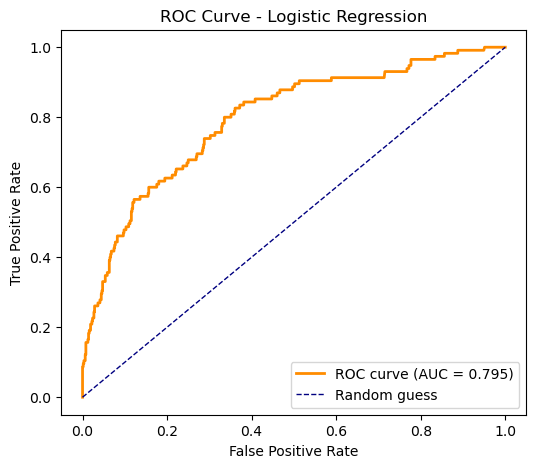

ROC-AUC Score: 0.7952


In [21]:
#20.PLOTTING THE ROC CURVE
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")


#from sklearn.metrics import roc_curve, roc_auc_score → imports the tools used to calculate ROC curve points and the ROC-AUC score
#fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba) → calculates the false positive rate (fpr), true positive rate (tpr), 
                                                               #and threshold values used to plot the ROC curve
#roc_auc = roc_auc_score(y_test, y_pred_proba) → calculates the overall ROC-AUC score, a single number summarizing model performance
#plt.figure(figsize=(6, 5)) → creates a new figure for the plot, sized 6x5 inches
#plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})') → plots the model's ROC curve in orange, 
                                                                                           #labeling it with the AUC score
#plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess') → plots a diagonal dashed line representing random guessing, 
                                                                                       #for comparison
#plt.xlabel('False Positive Rate') → labels the x-axis
#plt.ylabel('True Positive Rate') → labels the y-axis
#plt.title('ROC Curve - Logistic Regression') → sets the title of the plot
#plt.legend(loc='lower right') → displays the legend in the lower right corner
#plt.show() → displays the final plot
#print(f"ROC-AUC Score: {roc_auc:.4f}") → prints the ROC-AUC score rounded to 4 decimal places

#This code plots the ROC curve to show the model's ability to distinguish between classes visually, 
#along with the ROC-AUC score as a single performance measure — the closer to 1, the better the model.labelling

Best Threshold: 0.29
Best Average (Weighted) F1-Score: 0.8445


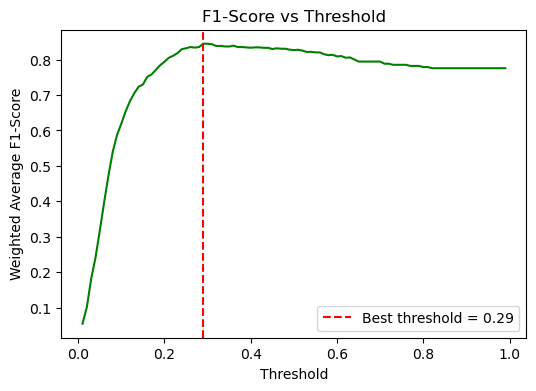

In [22]:
#21.FINDING THE BEST DECISION THRESHOLD USING F1-SCORE
from sklearn.metrics import f1_score
import numpy as np

candidate_thresholds = np.arange(0.01, 1.00, 0.01)
avg_f1_scores = []

for t in candidate_thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    avg_f1 = f1_score(y_test, y_pred_t, average='weighted', zero_division=0)
    avg_f1_scores.append(avg_f1)

best_index = np.argmax(avg_f1_scores)
best_threshold = candidate_thresholds[best_index]
best_avg_f1 = avg_f1_scores[best_index]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best Average (Weighted) F1-Score: {best_avg_f1:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(candidate_thresholds, avg_f1_scores, color='green')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Weighted Average F1-Score')
plt.title('F1-Score vs Threshold')
plt.legend()
plt.show()

#from sklearn.metrics import f1_score → imports the tool used to calculate the F1-score
#import numpy as np → loads numpy, used for numerical operations
#candidate_thresholds = np.arange(0.01, 1.00, 0.01) → creates a list of threshold values from 0.01 to 0.99, increasing by 0.01 each time
#avg_f1_scores = [] → creates an empty list to store the F1-score for each threshold
#for t in candidate_thresholds → loops through each threshold value one at a time
#y_pred_t = (y_pred_proba >= t).astype(int) → converts probabilities into 0/1 predictions, 
                                              #marking as 1 (positive) if the probability is at or above the current threshold t
#avg_f1 = f1_score(y_test, y_pred_t, average='weighted', zero_division=0) → calculates the weighted F1-score for this threshold, 
                                                                            #comparing predictions to actual values
#avg_f1_scores.append(avg_f1) → adds this threshold's F1-score to the results list
#best_index = np.argmax(avg_f1_scores) → finds the position of the highest F1-score in the list
#best_threshold = candidate_thresholds[best_index] → gets the threshold value that produced the highest F1-score
#best_avg_f1 = avg_f1_scores[best_index] → gets the highest F1-score itself
#print(f"Best Threshold: {best_threshold:.2f}") → displays the best threshold, rounded to 2 decimal places
#print(f"Best Average (Weighted) F1-Score: {best_avg_f1:.4f}") → displays the best F1-score, rounded to 4 decimal places
#plt.figure(figsize=(6, 4)) → creates a new figure for the plot, sized 6x4 inches
#plt.plot(candidate_thresholds, avg_f1_scores, color='green') → plots the F1-score against each threshold value, in green
#plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.2f}') → draws a red dashed vertical line 
                                                                                                            #marking the best threshold
#plt.xlabel('Threshold') → labels the x-axis
#plt.ylabel('Weighted Average F1-Score') → labels the y-axis
#plt.title('F1-Score vs Threshold') → sets the title of the plot
#plt.legend() → displays the legend
#plt.show() → displays the final plot

#This code tests many possible decision thresholds, finds the one that gives the best F1-score, 
#and plots how F1-score changes across thresholds — helping choose the optimal cutoff point for classifying predictions.

In [23]:
#22.EVALUATING THE MODEL AT THE OPTIMAL THRESHOLD
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

optimal_cm = confusion_matrix(y_test, y_pred_optimal)
optimal_clf_report = classification_report(y_test, y_pred_optimal)

print("Confusion Matrix (Optimal Threshold):")
print(optimal_cm)
print("\nClassification Report (Optimal Threshold):")
print(optimal_clf_report)

#y_pred_optimal = (y_pred_proba >= best_threshold).astype(int) → converts probabilities into 0/1 predictions 
                                                                 #using the best threshold found earlier, storing results in y_pred_optimal
#optimal_cm = confusion_matrix(y_test, y_pred_optimal) → compares actual values (y_test) with the new optimal predictions to show correct and 
                                                          #incorrect counts
#optimal_clf_report = classification_report(y_test, y_pred_optimal) → generates precision, recall, f1-score, 
                                                                       #and accuracy using the optimal threshold predictions
#print("Confusion Matrix (Optimal Threshold):") → prints a label for the confusion matrix output
#print(optimal_cm) → displays the confusion matrix
#print("\nClassification Report (Optimal Threshold):") → prints a label for the classification report output, 
                                                         #with \n adding a blank line before it
#print(optimal_clf_report) → displays the classification report

#This code re-evaluates the model using the best threshold instead of the default 0.5, and prints the updated confusion matrix 
#and classification report to see if performance improved.

Confusion Matrix (Optimal Threshold):
[[580  52]
 [ 62  53]]

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       632
           1       0.50      0.46      0.48       115

    accuracy                           0.85       747
   macro avg       0.70      0.69      0.70       747
weighted avg       0.84      0.85      0.84       747



In [24]:
#23.SAVING THE TRAINED MODEL
import pickle 
filename = "finalized_model_superstore_data.csv_Classification.sav"  #File name must be in .sav in the last

#import pickle   → Loads the pickle library, used to save the trained model to a file
#filename = "finalized_model_superstore_data.csv_Classification.sav"   → Sets the name of the file where the model will be saved
#filename must end in .sav                                              → Naming convention used so the file is recognized as a saved model

#This sets up the file name where the trained model will be saved for future use, without needing to retrain it.

In [25]:
#24.SAVING THE TRAINED MODEL TO A FILE
pickle.dump(classifier, open(filename, 'wb'))

#open(filename, 'wb')          → Opens the file in "write binary" mode, needed to save the model
#pickle.dump(classifier, ...)  → Saves the trained model (classifier) into that file

#This saves the trained model to disk, so it can be loaded and reused later without retraining.

In [26]:
#25.LOADING THE SAVED MODEL AND MAKING A PREDICTION
loaded_model = pickle.load(open("finalized_model_superstore_data.csv_Classification.sav", 'rb'))  
result = loaded_model.predict([[84835, 0, 0, 0, 189]]) 

#pickle.load(open("finalized_model_superstore_data.csv_Classification.sav", 'rb'))   → Loads the saved trained model back from file
#loaded_model = ...                                                                    → Stores the loaded model
#loaded_model.predict([[84835, 0, 0, 0, 189]])                                        → Uses the loaded model to predict an outcome for 
                                                                                        #this new data
#result = ...                                                                          → Stores the predicted result

#This loads the model we already trained and saved, then uses it to predict new data — without retraining.

In [27]:
#26.DISPLAYING THE PREDICTION RESULT
result

#result   → Displays the predicted outcome from the model

#This shows the final prediction made using the saved model and new input values.

array([0])